# NB1: Pangenome Architecture & Closure

**FunPan Aspergillus Pangenome Project**

Pipeline steps:

1. Orthogroup presence/absence (PAV) and copy-number (CNV) matrices per species
2. Core / accessory / rare classification by the S-curve inflection method
3. Pangenome openness by Heap's law with bootstrap confidence intervals
4. Orthogroup consensus annotation tables
5. Functional enrichment of the accessory genome against the core genome
6. SNP-derived kinship matrices
7. BGC and GCF presence/absence and copy-number matrices

All outputs are saved under `NB1_Results/`.

Analysis functions live in `funpan_utils.py` and `funpan_pangenome.py`. Sections 2
to 9 each open with a bootstrap cell that sets the paths, imports those modules and
reloads that section's inputs, so any section can be run on its own from a fresh
kernel. Edit the path block at the top of a bootstrap cell to point the notebook at
your own directories.

Set `FORCE = True` in any bootstrap cell to ignore cached tables and recompute from
source.

---
## Section 1: Configuration

- Paths, species list and the `NB1_Results/` output directory
- `FORCE` controls whether cached tables are reused or recomputed
- Reports which inputs are present and creates the output directories before anything runs


In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
GENUS        = 'Aspergillus'

RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB1_Results')
SPECIES_ROOT = os.path.join(SPECIES_DIR, GENUS)
NB0_RESULTS  = os.path.join(ANALYSIS_DIR, 'NB0_Results')

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, ANALYSIS_DIR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import funpan_utils as fpu
import funpan_pangenome as fpp

SPECIES_LIST = fpu.SPECIES_LIST

print(f'Species: {SPECIES_LIST}')
print(f'Results base: {RESULTS_BASE}')

# Reports which per-species inputs exist and creates the output directories.
# Nothing is computed or written beyond those directories.
status = fpp.nb1_preflight(SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, NB0_RESULTS)


Species: ['fumigatus', 'flavus', 'niger', 'oryzae']
Results base: /datadrive/Analysis/NB1_Results
NB1 preflight
  species root : /datadrive/Species/Aspergillus
  results base : /datadrive/Analysis/NB1_Results
  NB0 phenotype table: found
  -> /datadrive/Analysis/NB0_Results/phenotype_classified_for_gwas.csv

          species_dir orthofinder gubbins bigscape proteins genomes
species                                                            
fumigatus          ok          ok      ok       ok       ok      ok
flavus             ok          ok      ok       ok       ok      ok
niger              ok          ok      ok       ok       ok      ok
oryzae             ok          ok      ok       ok       ok      ok

All inputs present.


### 1.1 Phenotype labels

- Read from NB0, used to annotate the kinship figure in Section 7


In [2]:
PHENO_CSV = os.path.join(NB0_RESULTS, 'phenotype_classified_for_gwas.csv')
pheno_df = pd.read_csv(PHENO_CSV)
print(f'Phenotype table: {pheno_df.shape}')
pheno_df.head()

Phenotype table: (206, 69)


,Assembly Accession,Assembly Name,Organism Name,Organism Taxonomic ID,ANI Check status,Organism Infraspecific Names Breed,Organism Infraspecific Names Strain,Organism Infraspecific Names Cultivar,Organism Infraspecific Names Ecotype,Organism Infraspecific Names Isolate,...,PhenotypeScores,PhenotypeMatched,FieldProvenance,NegationsApplied,IsolationClass,IsolationSubclass,IsolationSubtype,ClassConfidence,ClassificationConfidence,UsageClass
0,GCA_000150145.1,ASM15014v1,Aspergillus fumigatus A1163,451804,NaN,NaN,A1163,NaN,NaN,NaN,...,"{""Human-pathogenic"": 10.0, ""Animal-pathogenic""...","{""Human-pathogenic"": [""Established strain: Asp...","{""Provenance:Clinical"": [""description"", ""comme...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
1,GCA_001599455.1,JCM_10253_assembly_v001,Aspergillus fumigatus var. fumigatus,41122,NaN,NaN,JCM 10253,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""description"", ""...",[],Environmental,Environmental,Environmental,low,low,Wild-type
2,GCA_001715275.2,ASM171527v2,Aspergillus fumigatus,746128,NaN,NaN,LMB-35Aa,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""isolation_sourc...",[],Environmental,Environmental,Environmental,low,low,Wild-type
3,GCA_015572005.1,ASM1557200v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA A,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
4,GCA_015572015.1,ASM1557201v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA B,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic


---
## Section 2: PAV and CNV Matrices

- `load_all_orthofinder()` reads the per-species OrthoFinder output and builds one row per orthogroup, one column per genome
- PAV records presence as 1 and absence as 0; CNV records the gene count
- Cached to `NB1_Results/{sp}/{sp}_pav.tsv` and `{sp}_cnv.tsv`
- Requires `Species/{genus}/{sp}/orthofinder_output`

In [3]:
# Standalone bootstrap: run this cell to use Section 2 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
GENUS        = 'Aspergillus'

RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB1_Results')
SPECIES_ROOT = os.path.join(SPECIES_DIR, GENUS)
NB0_RESULTS  = os.path.join(ANALYSIS_DIR, 'NB0_Results')

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, ANALYSIS_DIR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import funpan_utils as fpu
import funpan_pangenome as fpp

SPECIES_LIST = fpu.SPECIES_LIST


In [4]:
ortho_data, pav_data, cnv_data = fpp.load_all_orthofinder(
    SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, force=FORCE
)


=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae


---
## Section 3: Core / Accessory / Rare Classification

- Thresholds are derived per species by the S-curve inflection method
- `classify_all_pangenomes()` assigns every orthogroup a class and caches `{sp}_pangenome_class.tsv`
- Draws one gene-frequency histogram per species with the S-curve thresholds, saved to `{sp}_gene_freq_hist.png`
- Requires Section 2


In [5]:
# Standalone bootstrap: run this cell to use Section 3 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
GENUS        = 'Aspergillus'

RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB1_Results')
SPECIES_ROOT = os.path.join(SPECIES_DIR, GENUS)
NB0_RESULTS  = os.path.join(ANALYSIS_DIR, 'NB0_Results')

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, ANALYSIS_DIR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import funpan_utils as fpu
import funpan_pangenome as fpp

SPECIES_LIST = fpu.SPECIES_LIST

ortho_data, pav_data, cnv_data = fpp.load_all_orthofinder(
    SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, force=FORCE
)


=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae



=== fumigatus ===
  Loaded cached classification (837,154 OGs)
  Class counts:
Pangenome_Class
Core         748402
Accessory     85763
Rare           2989


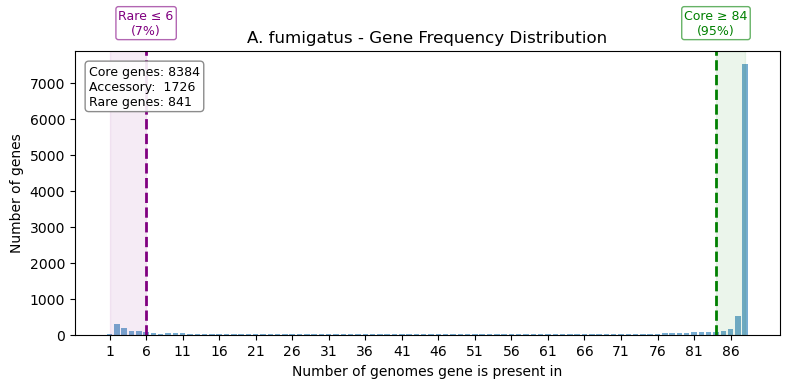


=== flavus ===
  Loaded cached classification (875,014 OGs)
  Class counts:
Pangenome_Class
Core         766141
Accessory    104463
Rare           4410


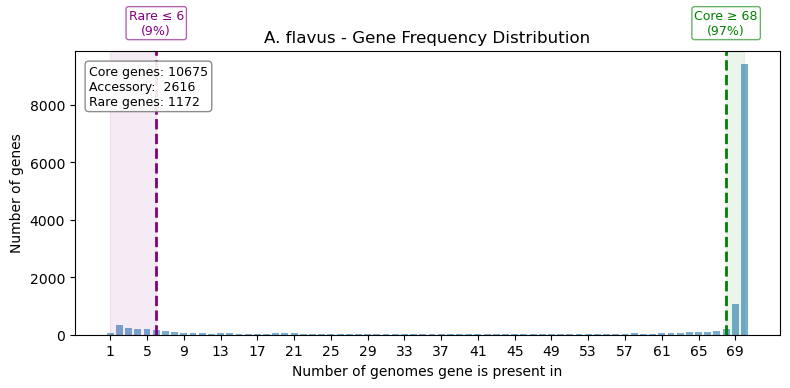


=== niger ===
  Loaded cached classification (209,403 OGs)
  Class counts:
Pangenome_Class
Core         180856
Accessory     27325
Rare           1222


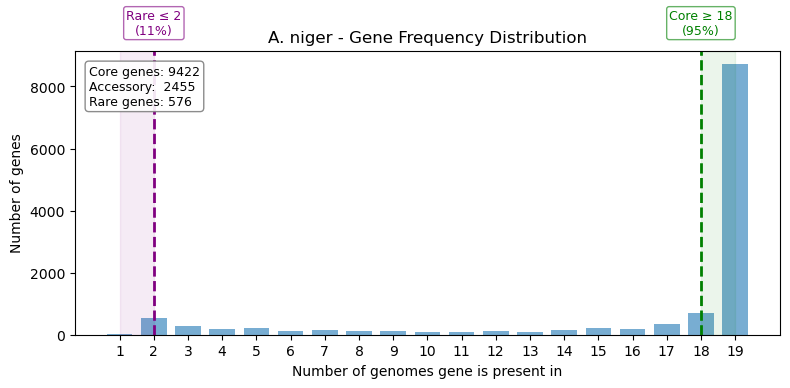


=== oryzae ===
  Loaded cached classification (416,657 OGs)
  Class counts:
Pangenome_Class
Core         368679
Accessory     46641
Rare           1337


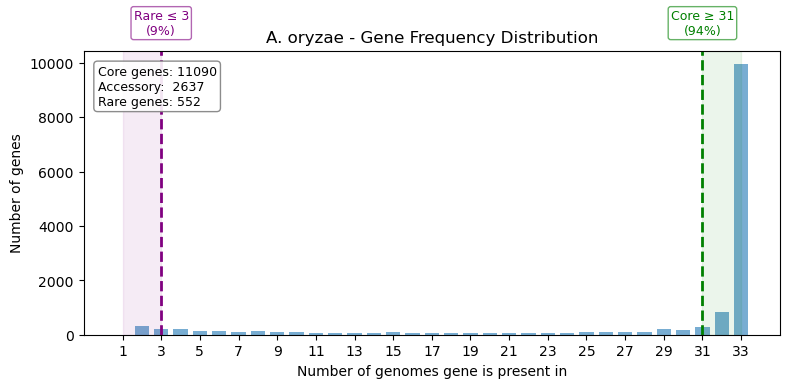

In [6]:
pangenome_class = fpp.classify_all_pangenomes(
    SPECIES_LIST, ortho_data, pav_data, RESULTS_BASE,
    force=FORCE, plot=True
)

### 3.1 Class counts per species

In [7]:
summary_df = fpp.pangenome_class_summary(pangenome_class, SPECIES_LIST)
print(summary_df.to_string(index=False))

  Species   Core  Core (%)  Accessory  Accessory (%)  Rare  Rare (%)
fumigatus 748402      89.4      85763           10.2  2989       0.4
   flavus 766141      87.6     104463           11.9  4410       0.5
    niger 180856      86.4      27325           13.0  1222       0.6
   oryzae 368679      88.5      46641           11.2  1337       0.3


In [8]:
print('Pangenome Classification Summary')
print('=' * 50)
for sp in SPECIES_LIST:
    if sp not in pangenome_class:
        continue
    cls = pangenome_class[sp]
    pav = pav_data[sp]
    n_genomes = pav.shape[1]
    counts = cls['Pangenome_Class'].value_counts()
    n_total = counts.sum()
    print(f'\nA. {sp} ({n_genomes} genomes, {n_total} orthogroups):')
    for cat in ['Core', 'Accessory', 'Rare']:
        n = counts.get(cat, 0)
        pct = 100 * n / n_total
        print(f'  {cat}: {n:,} ({pct:.1f}%)')

Pangenome Classification Summary

A. fumigatus (88 genomes, 837154 orthogroups):
  Core: 748,402 (89.4%)
  Accessory: 85,763 (10.2%)
  Rare: 2,989 (0.4%)

A. flavus (70 genomes, 875014 orthogroups):
  Core: 766,141 (87.6%)
  Accessory: 104,463 (11.9%)
  Rare: 4,410 (0.5%)

A. niger (19 genomes, 209403 orthogroups):
  Core: 180,856 (86.4%)
  Accessory: 27,325 (13.0%)
  Rare: 1,222 (0.6%)

A. oryzae (33 genomes, 416657 orthogroups):
  Core: 368,679 (88.5%)
  Accessory: 46,641 (11.2%)
  Rare: 1,337 (0.3%)


### 3.2 Pangenome composition figure

- Stacked bars of core, accessory and rare orthogroup counts, with percentages
- Orthogroups present in zero analysed genomes are dropped first; `load_all_orthofinder` removes ANI-excluded genomes from the PAV columns but leaves their orthogroup rows in place
- Saved to `NB1_Results/pangenome_composition_combined.png`

  fumigatus: dropped 70 orthogroup(s) absent from all 88 analysed genomes
  flavus: dropped 13 orthogroup(s) absent from all 70 analysed genomes
Saved: /datadrive/Analysis/NB1_Results/pangenome_composition_combined.png


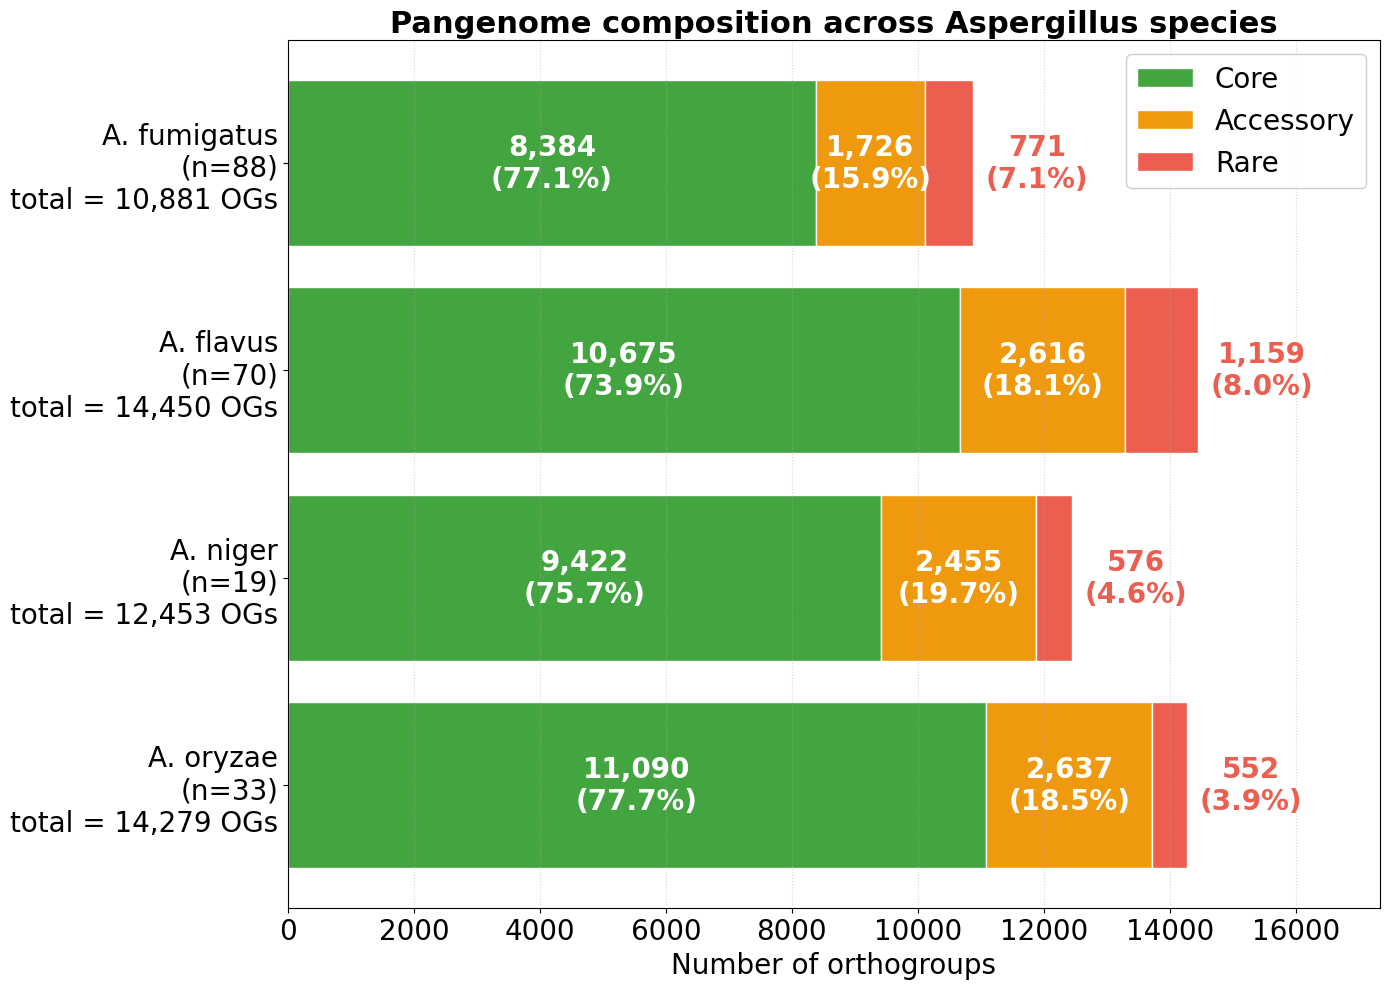


  species  n_genomes  core  accessory  rare  total
fumigatus         88  8384       1726   771  10881
   flavus         70 10675       2616  1159  14450
    niger         19  9422       2455   576  12453
   oryzae         33 11090       2637   552  14279


In [9]:
# --- Tweakable parameters ---
FONTSIZE     = 20
FIGSIZE      = (14, 10)
DPI          = 800
BAR_COLORS   = ("#0B8B08C5", "#ef990f", "#ec5e4f")   # core, accessory, rare
XLIM_FACTOR  = 1.20      # x headroom for the rare-count labels
LABEL_PAD    = 0.07      # rare label offset past the bar end, as a fraction of xmax

COMPOSITION_FIG = os.path.join(RESULTS_BASE, 'pangenome_composition_combined.png')

fig_comp, composition_counts = fpp.plot_pangenome_composition(
    pangenome_class, pav_data, SPECIES_LIST,
    out_path=COMPOSITION_FIG,
    fontsize=FONTSIZE,
    figsize=FIGSIZE,
    dpi=DPI,
    colors=BAR_COLORS,
    xlim_factor=XLIM_FACTOR,
    label_pad=LABEL_PAD,
)
plt.show()
print()
print(composition_counts.to_string(index=False))

---
## Section 4: Heap's Law

- Fits pangenome growth against the number of genomes sampled, with permutation confidence intervals
- Gamma below 0.05 is treated as a closed pangenome
- Cached to `NB1_Results/{sp}/{sp}_heaps.pkl`
- Requires Section 2

In [10]:
# Standalone bootstrap: run this cell to use Section 4 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
GENUS        = 'Aspergillus'

RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB1_Results')
SPECIES_ROOT = os.path.join(SPECIES_DIR, GENUS)
NB0_RESULTS  = os.path.join(ANALYSIS_DIR, 'NB0_Results')

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, ANALYSIS_DIR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import funpan_utils as fpu
import funpan_pangenome as fpp

SPECIES_LIST = fpu.SPECIES_LIST

ortho_data, pav_data, cnv_data = fpp.load_all_orthofinder(
    SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, force=FORCE
)


=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae


  fumigatus: loaded cached Heaps' law results (γ = 0.032, CLOSED)
  flavus: loaded cached Heaps' law results (γ = 0.038, CLOSED)
  niger: loaded cached Heaps' law results (γ = 0.048, CLOSED)
  oryzae: loaded cached Heaps' law results (γ = 0.035, CLOSED)


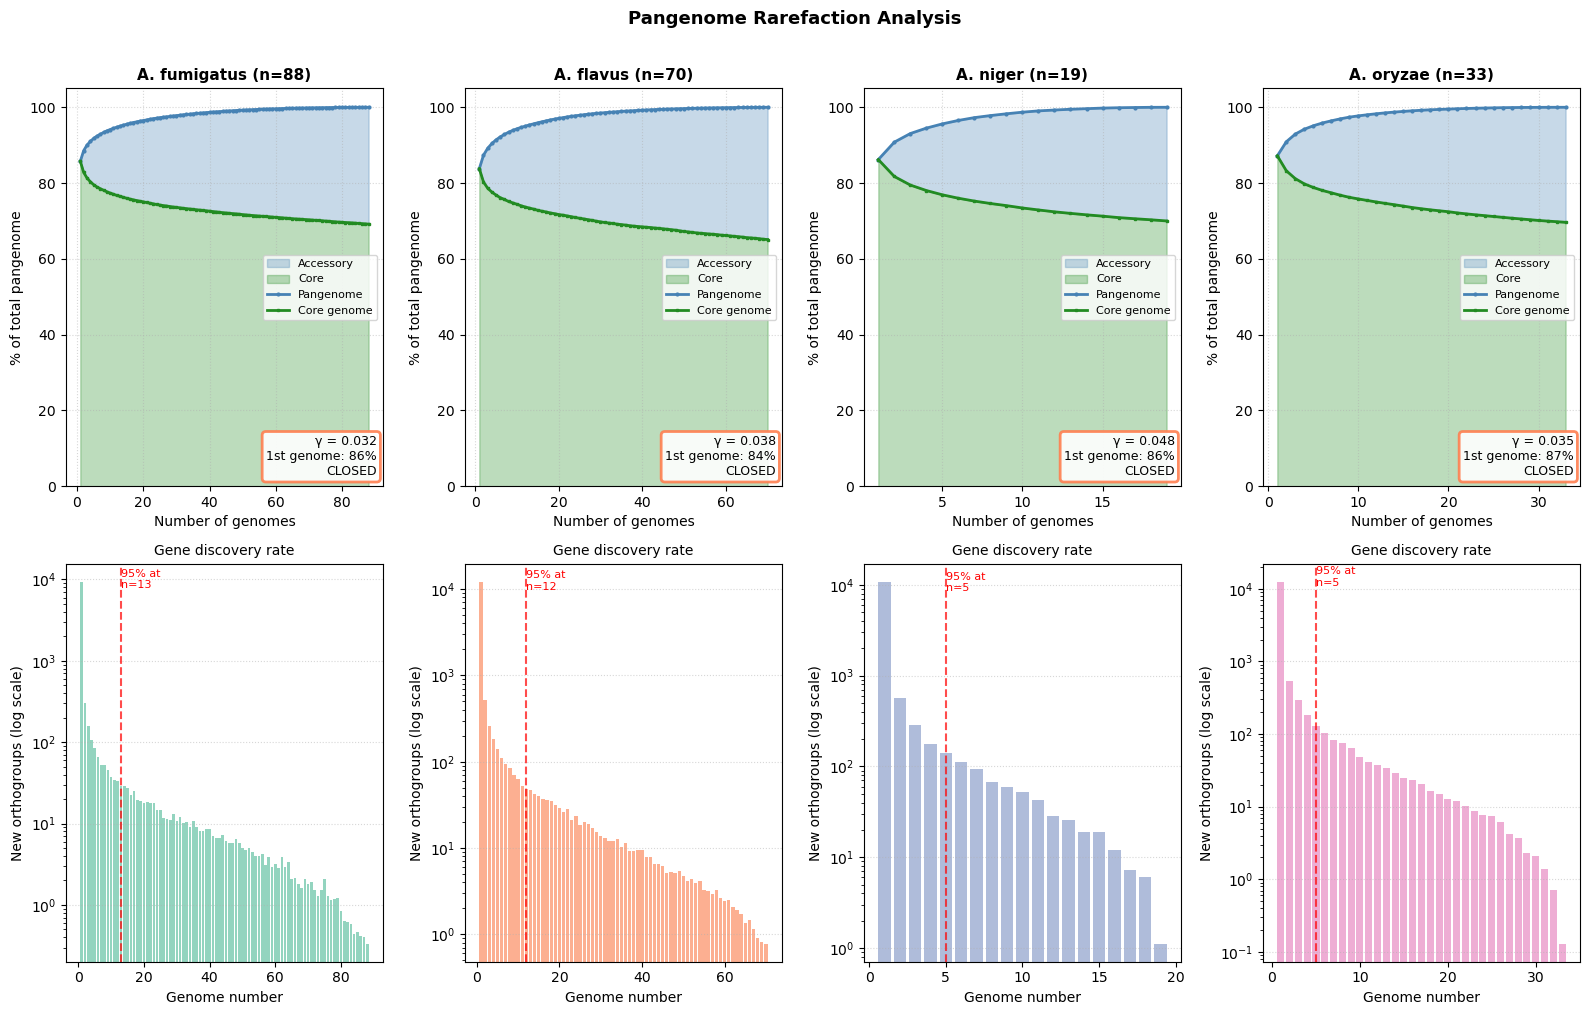

In [11]:
# --- Tweakable parameters ---
N_BOOT = 200     # permutation replicates for the confidence ribbons

orthofinder_data_dict = {sp: {'pav': pav_data[sp]} for sp in SPECIES_LIST if sp in pav_data}
heaps_results, _ = fpp.analyze_heaps_law(
    orthofinder_data_dict, SPECIES_LIST, n_boot=N_BOOT,
    results_base=RESULTS_BASE, force=FORCE
)

### 4.1 Gamma per species

In [12]:
print("Pangenome Openness (Heap's Law)")
print('=' * 50)
for sp, res in heaps_results.items():
    gamma = res.get('gamma', None)
    if gamma is not None:
        status_txt = 'CLOSED' if gamma < 0.05 else 'OPEN'
        print(f'  A. {sp}: gamma = {gamma:.4f} ({status_txt})')

Pangenome Openness (Heap's Law)
  A. fumigatus: gamma = 0.0321 (CLOSED)
  A. flavus: gamma = 0.0377 (CLOSED)
  A. niger: gamma = 0.0480 (CLOSED)
  A. oryzae: gamma = 0.0353 (CLOSED)


### 4.2 Accumulation and core decay figure

- Pangenome and core curves per species, normalised to each species' final pangenome size
- Shaded bands are 95% bootstrap confidence intervals
- Species colours come from `funpan_utils.SPECIES_COLORS`
- Saved to `NB1_Results/heaps_law_combined.png`

Saved: /datadrive/Analysis/NB1_Results/heaps_law_combined.png


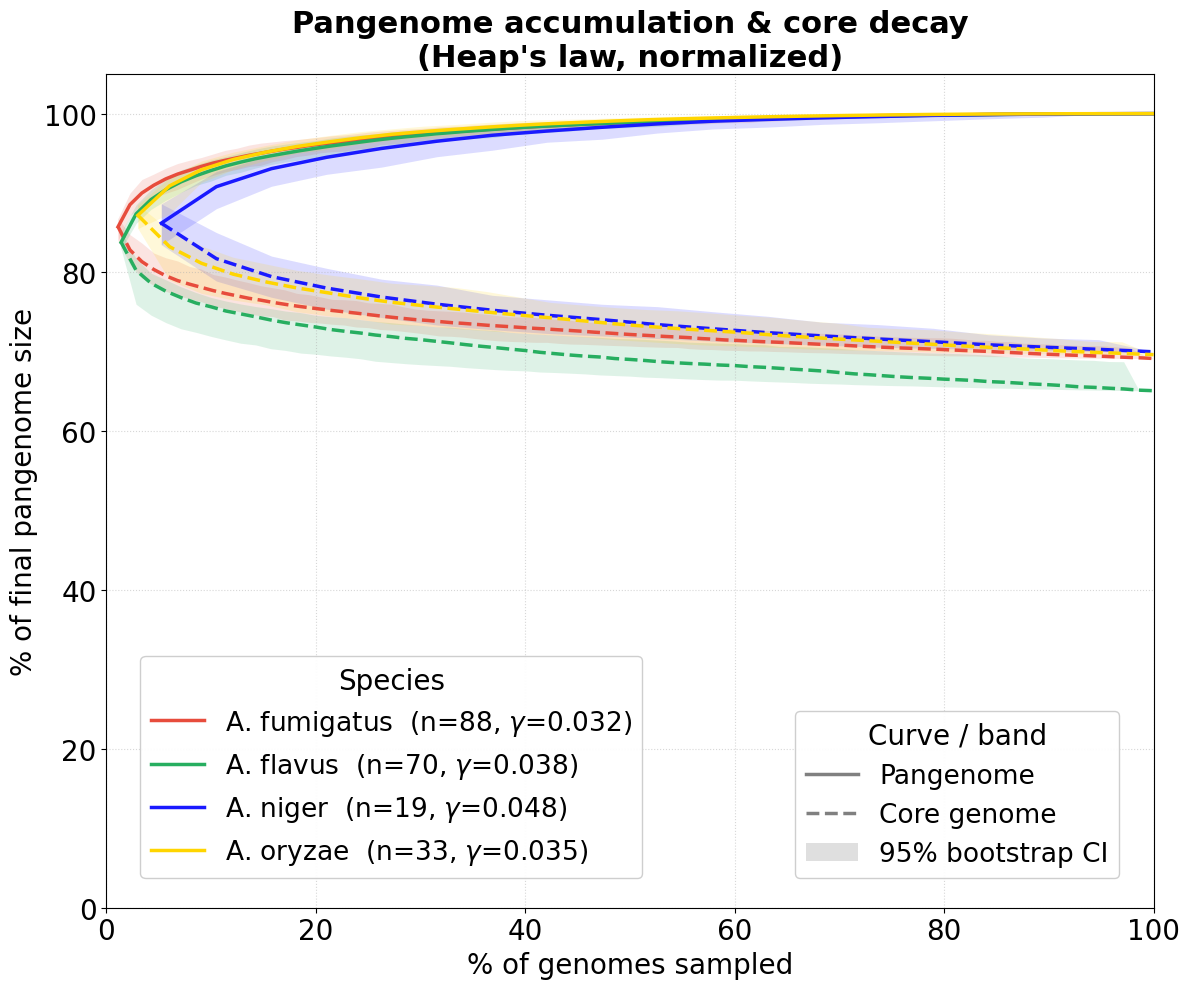

In [13]:
# --- Tweakable parameters ---
FONTSIZE = 20
FIGSIZE  = (12, 10)
DPI      = 800

HEAPS_FIG = os.path.join(RESULTS_BASE, 'heaps_law_combined.png')

fig_heaps = fpp.plot_heaps_law_curves(
    SPECIES_LIST, RESULTS_BASE,
    out_path=HEAPS_FIG,
    fontsize=FONTSIZE,
    figsize=FIGSIZE,
    dpi=DPI,
)
plt.show()

---
## Section 5: Orthogroup Annotation Tables

- Combines the EggNOG, InterProScan, dbCAN and SignalP per-protein outputs into one row per orthogroup
- Cached to `NB1_Results/{sp}/{sp}_og_consensus.tsv`
- Read by NB2 to NB5
- Requires Sections 2 and 3

In [14]:
# Standalone bootstrap: run this cell to use Section 5 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
GENUS        = 'Aspergillus'

RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB1_Results')
SPECIES_ROOT = os.path.join(SPECIES_DIR, GENUS)
NB0_RESULTS  = os.path.join(ANALYSIS_DIR, 'NB0_Results')

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, ANALYSIS_DIR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import funpan_utils as fpu
import funpan_pangenome as fpp

SPECIES_LIST = fpu.SPECIES_LIST

ortho_data, pav_data, cnv_data = fpp.load_all_orthofinder(
    SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, force=FORCE
)
pangenome_class = fpp.classify_all_pangenomes(
    SPECIES_LIST, ortho_data, pav_data, RESULTS_BASE,
    force=FORCE, plot=False
)


=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae

=== fumigatus ===
  Loaded cached classification (837,154 OGs)
  Class counts:
Pangenome_Class
Core         748402
Accessory     85763
Rare           2989

=== flavus ===
  Loaded cached classification (875,014 OGs)
  Class counts:
Pangenome_Class
Core         766141
Accessory    104463
Rare           4410

=== niger ===
  Loaded cached classification (209,403 OGs)
  Class counts:
Pangenome_Class
Core         180856
Accessory     27325
Rare           1222

=== oryzae ===
  Loaded cached classification (416,657 OGs)
  Class co

In [15]:
og_consensus = fpp.load_all_annotations_and_consensus(
    SPECIES_LIST, SPECIES_ROOT, ortho_data, pangenome_class, pav_data,
    RESULTS_BASE, force=FORCE
)


=== fumigatus ===
  Loaded cached OG consensus table: (10951, 23)

=== flavus ===
  Loaded cached OG consensus table: (14463, 23)

=== niger ===
  Loaded cached OG consensus table: (12453, 23)

=== oryzae ===
  Loaded cached OG consensus table: (14279, 23)


---
## Section 6: Functional Enrichment

- Fisher's exact test per annotation layer, accessory genome against core genome
- Ten layers per species, cached to `NB1_Results/{sp}/{sp}_enrichment_{layer}.tsv`
- Requires Section 5


In [16]:
# Standalone bootstrap: run this cell to use Section 6 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
GENUS        = 'Aspergillus'

RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB1_Results')
SPECIES_ROOT = os.path.join(SPECIES_DIR, GENUS)
NB0_RESULTS  = os.path.join(ANALYSIS_DIR, 'NB0_Results')

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, ANALYSIS_DIR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import funpan_utils as fpu
import funpan_pangenome as fpp

SPECIES_LIST = fpu.SPECIES_LIST

ortho_data, pav_data, cnv_data = fpp.load_all_orthofinder(
    SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, force=FORCE
)
pangenome_class = fpp.classify_all_pangenomes(
    SPECIES_LIST, ortho_data, pav_data, RESULTS_BASE,
    force=FORCE, plot=False
)
og_consensus = fpp.load_all_annotations_and_consensus(
    SPECIES_LIST, SPECIES_ROOT, ortho_data, pangenome_class, pav_data,
    RESULTS_BASE, force=FORCE
)


=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae

=== fumigatus ===
  Loaded cached classification (837,154 OGs)
  Class counts:
Pangenome_Class
Core         748402
Accessory     85763
Rare           2989

=== flavus ===
  Loaded cached classification (875,014 OGs)
  Class counts:
Pangenome_Class
Core         766141
Accessory    104463
Rare           4410

=== niger ===
  Loaded cached classification (209,403 OGs)
  Class counts:
Pangenome_Class
Core         180856
Accessory     27325
Rare           1222

=== oryzae ===
  Loaded cached classification (416,657 OGs)
  Class co

In [17]:
enrichment_results = fpp.run_all_enrichment(
    SPECIES_LIST, og_consensus, RESULTS_BASE, force=FORCE, plot=False
)


=== fumigatus ===
  Loaded 10 cached enrichment layers from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded 10 cached enrichment layers from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded 10 cached enrichment layers from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded 10 cached enrichment layers from /datadrive/Analysis/NB1_Results/oryzae


### 6.1 Significant terms per layer

- Top five terms by q-value for each species and layer passing FDR < 0.05

In [18]:
print('Functional Enrichment Summary (Core vs Accessory)')
print('=' * 60)
for sp, enr in enrichment_results.items():
    if not isinstance(enr, dict):
        continue
    for layer, df_enr in enr.items():
        if not hasattr(df_enr, 'query') or 'q_value' not in df_enr.columns:
            continue
        sig = df_enr[df_enr['q_value'] < 0.05]
        if len(sig) > 0:
            print(f'\nA. {sp} | {layer}: {len(sig)} significant terms (FDR < 0.05)')
            top = sig.nsmallest(5, 'q_value')
            for _, row in top.iterrows():
                term = row.get('Term', '?')
                odds = row.get('Odds_Ratio', 0)
                pclass = row.get('Pangenome_Class', '?')
                direction = row.get('Direction', '')
                print(f'    [{pclass}] {term}: OR={odds:.2f} ({direction})')

Functional Enrichment Summary (Core vs Accessory)

A. fumigatus | COG/category: 14 significant terms (FDR < 0.05)
    [Core] J: OR=1.96 (enriched)
    [Core] A: OR=2.17 (enriched)
    [Core] O: OR=1.67 (enriched)
    [Core] U: OR=1.66 (enriched)
    [Core] V: OR=0.35 (depleted)

A. fumigatus | KEGG/TC: 3 significant terms (FDR < 0.05)
    [Accessory] 9.B.37.1: OR=41.87 (enriched)
    [Accessory] 2.A.1.2.16: OR=10.61 (enriched)
    [Core] 2.A.1.2.16: OR=0.13 (depleted)

A. fumigatus | GOs: 2 significant terms (FDR < 0.05)
    [Accessory] GO:0044262: OR=9.97 (enriched)
    [Core] GO:0034406: OR=0.14 (depleted)

A. fumigatus | PFAMs: 34 significant terms (FDR < 0.05)
    [Core] Zn_clus: OR=0.29 (depleted)
    [Core] MFS_1: OR=0.22 (depleted)
    [Core] Pkinase: OR=0.12 (depleted)
    [Core] Ank_2: OR=0.23 (depleted)
    [Accessory] Pkinase: OR=6.80 (enriched)

A. fumigatus | EC: 1 significant terms (FDR < 0.05)
    [Core] 2.4.1.-:33: OR=0.07 (depleted)

A. fumigatus | KEGG/ko: 7 significa

---
## Section 7: Kinship Matrices

- Builds the SNP-derived genetic relatedness matrix per species from the Gubbins core alignment
- Cached to `NB1_Results/{sp}/{sp}_kinship.tsv`, with SNP principal components in `{sp}_snp_pcs.tsv`
- The kinship matrix is the random-effect covariance in the NB2 pan-GWAS
- Requires `Species/{genus}/{sp}/gubbins_output`


In [19]:
# Standalone bootstrap: run this cell to use Section 7 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
GENUS        = 'Aspergillus'

RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB1_Results')
SPECIES_ROOT = os.path.join(SPECIES_DIR, GENUS)
NB0_RESULTS  = os.path.join(ANALYSIS_DIR, 'NB0_Results')

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, ANALYSIS_DIR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import funpan_utils as fpu
import funpan_pangenome as fpp

SPECIES_LIST = fpu.SPECIES_LIST


In [20]:
snp_results = fpp.run_all_snp_pca_and_grm(
    SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, force=FORCE, plot=False
)


=== fumigatus ===
  Loaded cached SNP PCs ((88, 11)) and GRM ((88, 88))

=== flavus ===
  Loaded cached SNP PCs ((70, 11)) and GRM ((70, 70))

=== niger ===
  Loaded cached SNP PCs ((19, 11)) and GRM ((19, 19))

=== oryzae ===
  Loaded cached SNP PCs ((33, 11)) and GRM ((33, 33))


### 7.1 Kinship figure

- Clustered relatedness matrix per species, with each strain's phenotype as a colour strip on the top and left edges
- Shows the strains used in the pan-GWAS: ANI-excluded genomes and strains without a phenotype label are left out
- Diagonal is masked; colour limits come from off-diagonal percentiles
- Saved to `NB1_Results/kinship_grm_combined.png`


  fumigatus: dropped 3 strain(s) with no phenotype label
  flavus: dropped 1 strain(s) with no phenotype label
Saved: /datadrive/Analysis/NB1_Results/kinship_grm_combined.png


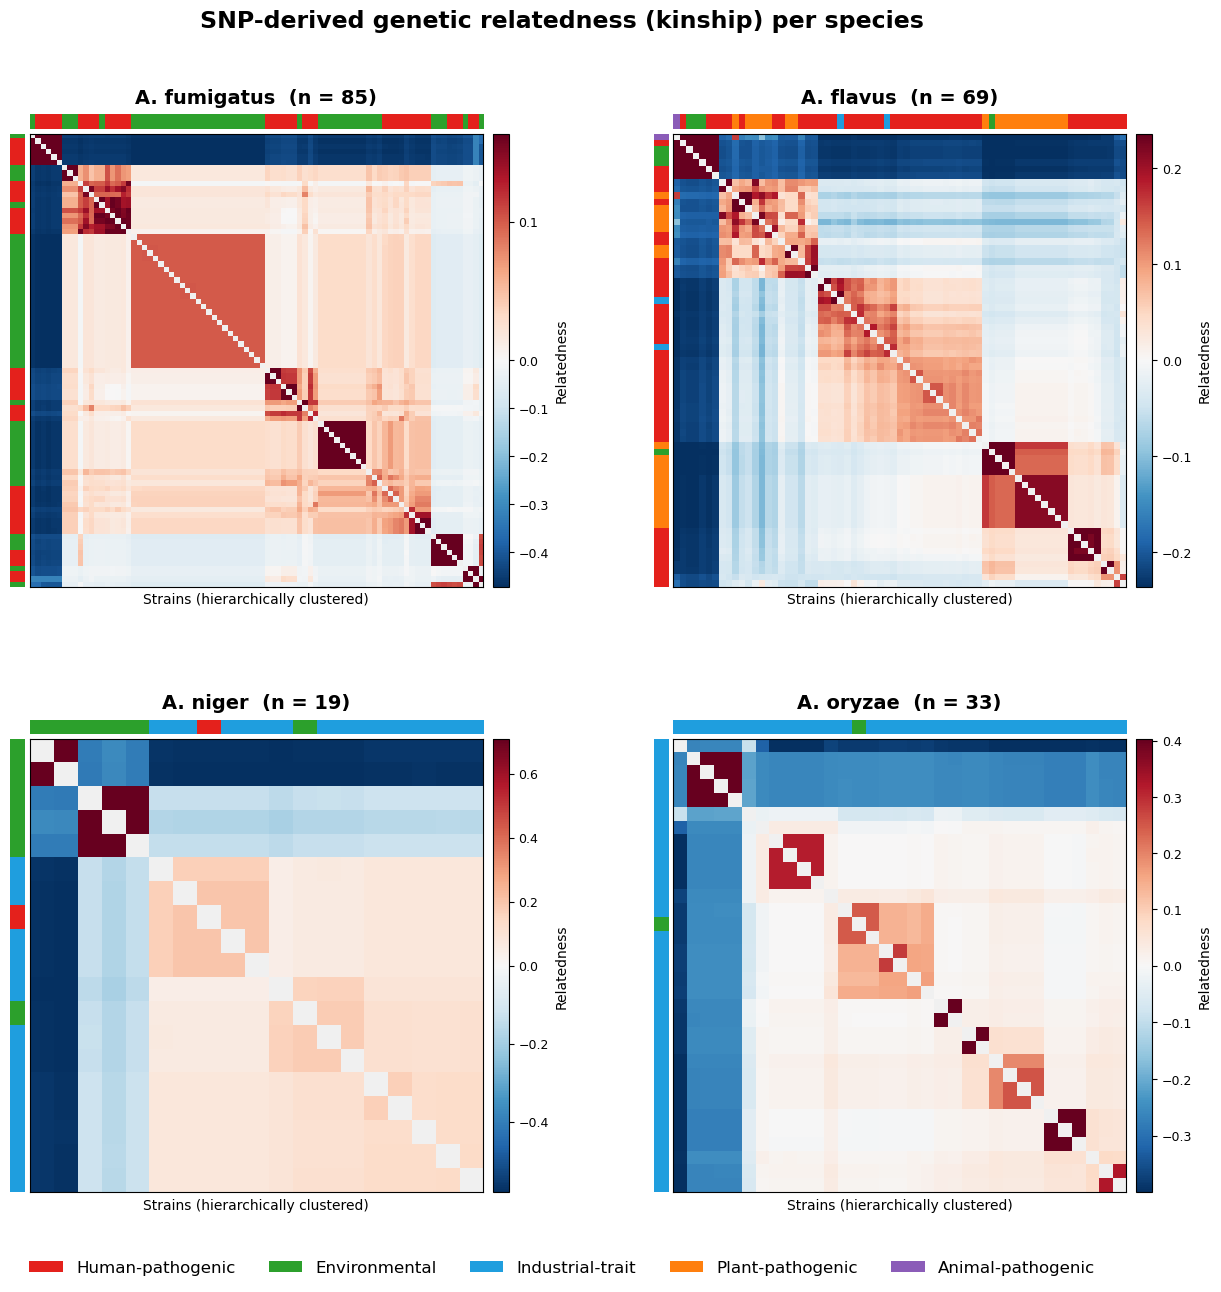

In [21]:
# --- Tweakable parameters ---
FIGSIZE         = (15, 14)
DPI             = 300
FONTSIZE        = 13
CLIP_PCT        = (2, 98)   # colour limits from off-diagonal percentiles
LINKAGE         = 'average' # scipy linkage method for the strain ordering
LEFT_STRIP      = True      # phenotype strip down the left edge as well as the top
DROP_UNLABELLED = True      # True keeps only the strains the pan-GWAS tested

PHENO_CSV   = os.path.join(NB0_RESULTS, 'phenotype_classified_for_gwas.csv')
KINSHIP_FIG = os.path.join(RESULTS_BASE, 'kinship_grm_combined.png')

fig_k, kinship_order = fpp.plot_kinship_grid(
    SPECIES_LIST, RESULTS_BASE, PHENO_CSV,
    out_path=KINSHIP_FIG,
    figsize=FIGSIZE,
    dpi=DPI,
    fontsize=FONTSIZE,
    clip_pct=CLIP_PCT,
    method=LINKAGE,
    show_left_strip=LEFT_STRIP,
    drop_unlabelled=DROP_UNLABELLED,
)
plt.show()

---
## Section 8: BGC and GCF Matrices

- Builds BGC presence/absence, GCF presence/absence and GCF copy-number matrices from the BiG-SCAPE clustering
- Cached to `NB1_Results/{sp}/{sp}_bgc_pav.tsv`, `{sp}_gcf_pav.tsv`, `{sp}_gcf_cnv.tsv`
- The three matrices are feature layers in the NB2 pan-GWAS
- Requires `Species/{genus}/{sp}/bigscape_output`


In [22]:
# Standalone bootstrap: run this cell to use Section 8 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
GENUS        = 'Aspergillus'

RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB1_Results')
SPECIES_ROOT = os.path.join(SPECIES_DIR, GENUS)
NB0_RESULTS  = os.path.join(ANALYSIS_DIR, 'NB0_Results')

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, ANALYSIS_DIR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import funpan_utils as fpu
import funpan_pangenome as fpp

SPECIES_LIST = fpu.SPECIES_LIST


In [23]:
bgc_results = fpp.run_all_bgc_gcf(
    SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, force=FORCE, plot=False
)


=== fumigatus ===
  Loaded cached BGC matrices: BGC_PAV (88, 3707), GCF_PAV (88, 74), GCF_CNV (88, 74)

=== flavus ===
  Loaded cached BGC matrices: BGC_PAV (70, 5703), GCF_PAV (70, 154), GCF_CNV (70, 154)

=== niger ===
  Loaded cached BGC matrices: BGC_PAV (19, 1656), GCF_PAV (19, 139), GCF_CNV (19, 139)

=== oryzae ===
  Loaded cached BGC matrices: BGC_PAV (33, 2702), GCF_PAV (33, 129), GCF_CNV (33, 129)


### 8.1 GCF annotation

- One row per GCF with its antiSMASH class and BiG-SCAPE category
- `mibig_in_family`: MIBiG reference BGCs clustered into the family
- `kcb_top_*`: best knownclusterblast hit, ranked by member regions recovering it
- `kcb_support`: fraction of member regions carrying that hit
- ANI-excluded genomes are dropped, matching the GCF matrices
- Writes `{sp}_gcf_annotation.tsv`

In [24]:
gcf_annotation = fpp.run_all_gcf_annotation(
    SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, force=FORCE
)


=== fumigatus ===
  Loaded cached GCF annotation: (74, 17)

=== flavus ===
  Loaded cached GCF annotation: (152, 17)

=== niger ===
  Loaded cached GCF annotation: (139, 17)

=== oryzae ===
  Loaded cached GCF annotation: (129, 17)


#### 8.1.1 Annotation summary

- MIBiG evidence counts per species
- GCF counts per BiG-SCAPE category

In [25]:
annot_summary, category_composition = fpp.summarise_gcf_annotation(gcf_annotation)

print('MIBiG evidence per species')
print(annot_summary.to_string())
print('\nGCFs by BiG-SCAPE category')
category_composition

MIBiG evidence per species
           GCFs  regions  MIBiG ref in family  confident KCB hit  no MIBiG evidence
fumigatus    74     3707                   14                 38                 36
flavus      152     5703                   21                 60                 92
niger       139     1656                   13                 39                 98
oryzae      129     2702                   21                 55                 74

GCFs by BiG-SCAPE category


,fumigatus,flavus,niger,oryzae
bigscape_category,,,,
NRPS,22,35,25,28
NRPS.PKS,3,10,19,8
NRPS.PKS.other,1,1,0,1
NRPS.PKS.other.terpene,1,0,0,0
NRPS.PKS.terpene,0,2,3,1
NRPS.other,1,2,0,1
NRPS.terpene,1,7,4,6
PKS,11,30,28,27
PKS.other,1,0,0,0


---
## Section 9: Summary

- Final core, accessory and rare orthogroup counts per species, with Heap's law gamma
- Every output file with its full path under `NB1_Results/`


In [26]:
# Standalone bootstrap: run this cell to use Section 9 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
GENUS        = 'Aspergillus'

RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB1_Results')
SPECIES_ROOT = os.path.join(SPECIES_DIR, GENUS)
NB0_RESULTS  = os.path.join(ANALYSIS_DIR, 'NB0_Results')

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, ANALYSIS_DIR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import funpan_utils as fpu
import funpan_pangenome as fpp

SPECIES_LIST = fpu.SPECIES_LIST

ortho_data, pav_data, cnv_data = fpp.load_all_orthofinder(
    SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE, force=FORCE
)
pangenome_class = fpp.classify_all_pangenomes(
    SPECIES_LIST, ortho_data, pav_data, RESULTS_BASE,
    force=FORCE, plot=False
)



=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae

=== fumigatus ===
  Loaded cached classification (837,154 OGs)
  Class counts:
Pangenome_Class
Core         748402
Accessory     85763
Rare           2989

=== flavus ===
  Loaded cached classification (875,014 OGs)
  Class counts:
Pangenome_Class
Core         766141
Accessory    104463
Rare           4410

=== niger ===
  Loaded cached classification (209,403 OGs)
  Class counts:
Pangenome_Class
Core         180856
Accessory     27325
Rare           1222

=== oryzae ===
  Loaded cached classification (416,657 OGs)
  Class co

In [27]:
summary_counts, summary_files = fpp.print_nb1_summary(
    pangenome_class, pav_data, SPECIES_LIST, RESULTS_BASE
)
display(summary_counts)



NB1 Pangenome Architecture complete.
All outputs saved to: /datadrive/Analysis/NB1_Results
    /datadrive/Analysis/NB1_Results/pangenome_composition_combined.png
    /datadrive/Analysis/NB1_Results/heaps_law_combined.png
    /datadrive/Analysis/NB1_Results/kinship_grm_combined.png
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_pav.tsv
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_cnv.tsv
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_pangenome_class.tsv
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_gene_freq_hist.png
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_heaps.pkl
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_og_consensus.tsv
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_enrichment_*.tsv  (10 files)
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_snp_pcs.tsv
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_kinship.tsv
    /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_bgc_pav.tsv
    /datad

,n_genomes,core,accessory,rare,total,heaps_gamma
species,,,,,,
fumigatus,88,8384,1726,771,10881,0.0321
flavus,70,10675,2616,1159,14450,0.0377
niger,19,9422,2455,576,12453,0.0480
oryzae,33,11090,2637,552,14279,0.0353
